# PriorSampler Test (FEniCSx)

This notebook tests the FEniCSx `PriorSampler` class for generating uncertain parameter fields.

Run in the `neuralopv2` conda environment from this directory:

```bash
conda activate neuralopv2
jupyter lab PriorSampler.ipynb
```

Figures are saved under `results/`.

## Uncertain parameter and covariance operator

Consider an uncertain field $w$ on $D = (0,1)^2$ with distribution $w \sim N(0, C)$, where $C = L_\Delta^{-2}$ and

$$
L_\Delta := \begin{cases}
    -\mathsf{a}_c \nabla \cdot \mathsf{b}_c \nabla + \mathsf{c}_c\,, & \text{in } D_w\,,\\
    \gamma n \cdot \mathsf{b}_c \nabla\,, & \text{on }\partial D_w\,.
\end{cases}
$$

We use $\mathsf{a} = 0.01$, $\mathsf{c} = 0.2$, and test constant, inhomogeneous, and smooth diffusivity fields $\mathsf{b}$.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from dolfinx.fem import functionspace
from mpi4py import MPI
from mpl_toolkits.axes_grid1 import make_axes_locatable

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parents[2]
sys.path.insert(0, str(ROOT / "src/plotting"))
sys.path.insert(0, str(ROOT / "src/pde"))
sys.path.insert(0, str(ROOT / "src/prior"))

from field_plot import field_plot, quick_field_plot
from fenicsUtilities import function_to_vertex
from meshUtilities import load_legacy_unit_square_mesh
from priorSampler import PriorSampler

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

seed = 0
np.random.seed(seed)

results_dir = NOTEBOOK_DIR / "results"
results_dir.mkdir(exist_ok=True)
print(f"Repo root: {ROOT}")
print(f"Results:   {results_dir}")

Repo root: /Users/prashant/Dropbox/Work/Simulations/neuralnet_works/error_corrector_direction/neural_operators
Results:   /Users/prashant/Dropbox/Work/Simulations/neuralnet_works/error_corrector_direction/neural_operators/survey_work/common/prior_sampler/results


## Create PriorSampler model

a = 0.01, c = 0.2


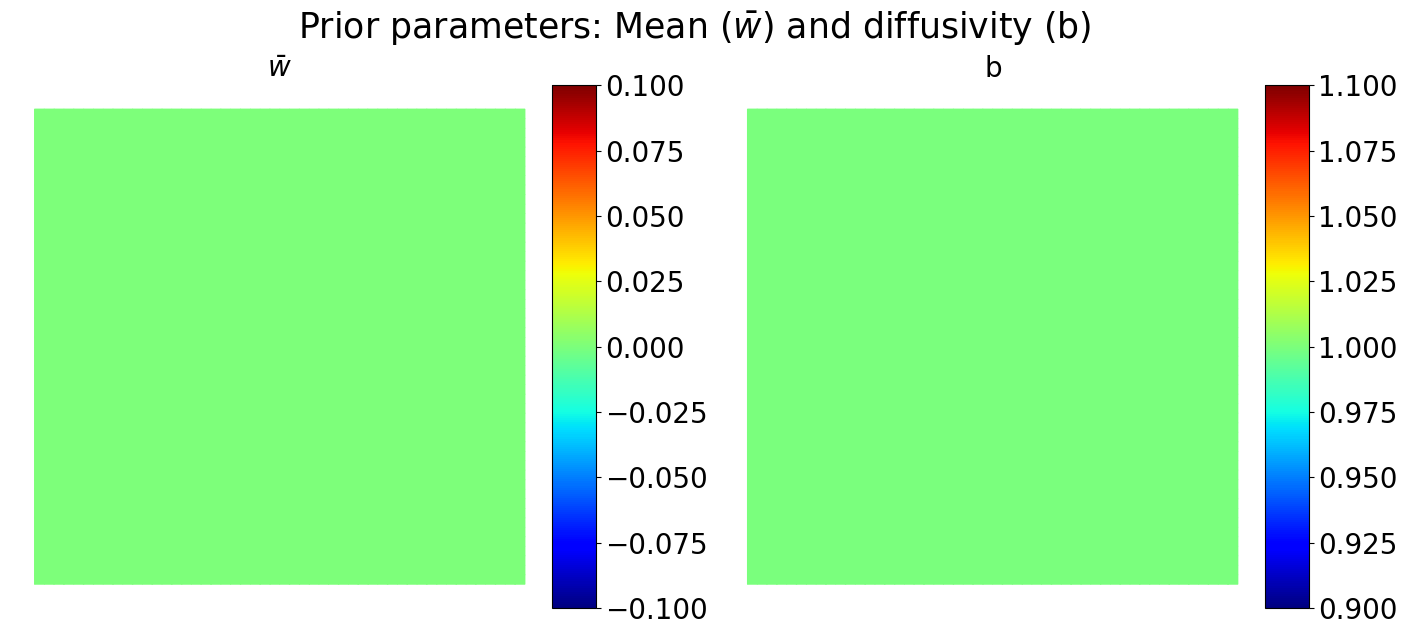

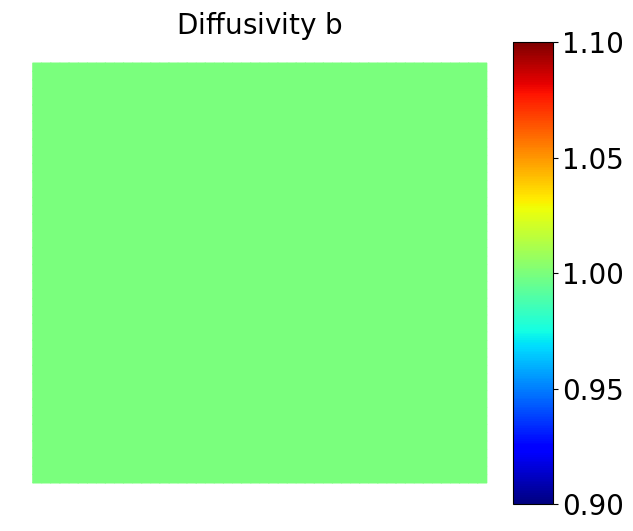

In [2]:
prior_ac = 0.01
prior_cc = 0.2
fe_order = 1
nx, ny = 50, 50

# Same mesh as legacy UnitSquareMesh(nx, ny) — exported to XDMF
domain = load_legacy_unit_square_mesh(MPI.COMM_WORLD, nx, ny)
V = functionspace(domain, ("Lagrange", fe_order))
nodes = domain.geometry.x

prior_sampler = PriorSampler(V, prior_ac, prior_cc, seed=seed)
print(f"a = {float(prior_sampler.a.value)}, c = {float(prior_sampler.c.value)}")

fs = 20
rows, cols = 1, 2
fig, axs = plt.subplots(rows, cols, figsize=(14, 6))
axs = np.array([axs]) if rows == 1 else axs

for j in range(cols):
    m = (
        prior_sampler.mean
        if j == 0
        else function_to_vertex(prior_sampler.b_fn, V=V)
    )
    cbar = field_plot(axs[0, j], m, nodes, cmap="jet")
    divider = make_axes_locatable(axs[0, j])
    cax = divider.append_axes("right", size="8%", pad=0.03)
    cax.tick_params(labelsize=fs)
    fig.colorbar(cbar, cax=cax, orientation="vertical")
    axs[0, j].set_title(r"$\bar{w}$" if j == 0 else r"$\mathsf{b}$", fontsize=fs)
    axs[0, j].axis("off")

fig.tight_layout()
fig.suptitle(
    r"Prior parameters: Mean ($\bar{w}$) and diffusivity ($\mathsf{b}$)",
    fontsize=1.25 * fs,
    y=1.05,
)
fig.savefig(results_dir / "const_b_prior_parameters.png", bbox_inches="tight")
plt.show()

quick_field_plot(
    function_to_vertex(prior_sampler.b_fn, V=V),
    nodes,
    title=r"Diffusivity $\mathsf{b}$",
    cmap="jet",
    figsize=(7, 6),
    fs=20,
    savefilename=str(results_dir / "const_b.png"),
)

## Generate random samples (constant diffusivity)

Sample:  0, log_prior = -6.92e-01, min = -3.73e-01, max = 3.16e-01, mean = -1.13e-01, std = 1.29e-01
Sample:  1, log_prior = -7.10e-01, min = -5.30e-01, max = 1.89e-01, mean = -6.93e-02, std = 1.41e-01
Sample:  2, log_prior = -6.98e-01, min = -2.03e-01, max = 2.33e-01, mean = -2.50e-02, std = 7.55e-02
Sample:  3, log_prior = -6.95e-01, min = -6.34e-01, max = 2.05e-01, mean = -1.68e-01, std = 2.14e-01
Sample:  4, log_prior = -7.07e-01, min = -7.07e-01, max = 3.03e-01, mean = -7.79e-02, std = 1.66e-01
Sample:  5, log_prior = -6.93e-01, min = -1.11e-01, max = 3.66e-01, mean = 1.29e-01, std = 9.62e-02
Sample:  6, log_prior = -6.98e-01, min = -1.68e-01, max = 4.48e-01, mean = 9.37e-02, std = 1.50e-01
Sample:  7, log_prior = -7.10e-01, min = -2.77e-01, max = 3.71e-01, mean = 8.67e-02, std = 1.16e-01
Sample:  8, log_prior = -7.04e-01, min = -1.27e-01, max = 4.18e-01, mean = 8.23e-02, std = 8.42e-02
Statistics of all samples
Mean: min = -3.48e-01, max = 3.17e-01, mean = -6.86e-03, std = 1.30e-

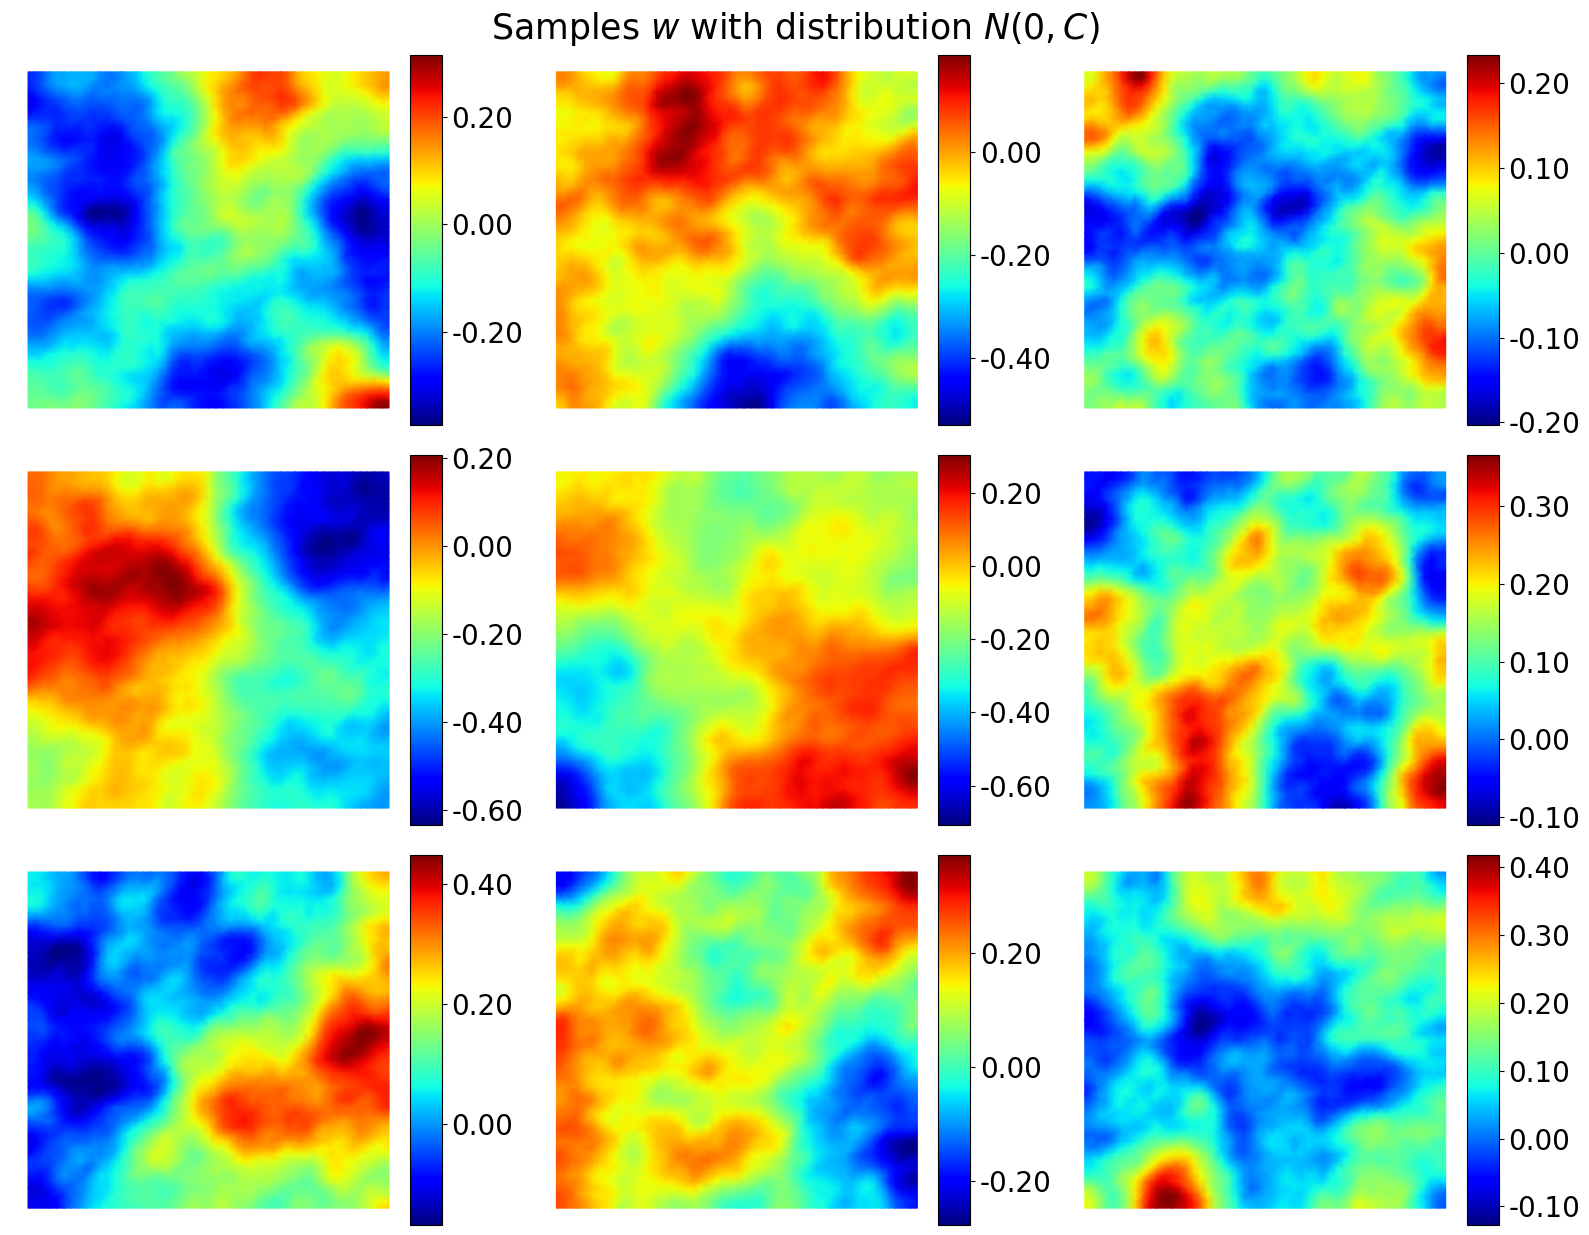

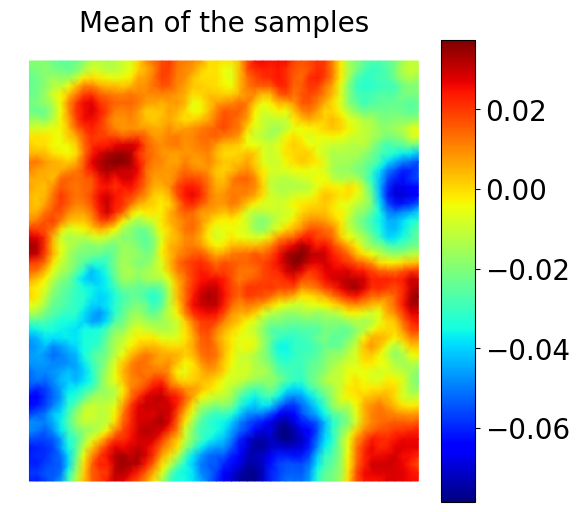

CPU times: user 1.1 s, sys: 1.11 s, total: 2.21 s
Wall time: 743 ms


In [3]:
%%time

fs = 20
rows, cols = 3, 3
fig, axs = plt.subplots(rows, cols, figsize=(16, 12))
stats = []
mvec = []
m = prior_sampler.empty_sample()

for i in range(rows):
    for j in range(cols):
        m, log_prior = prior_sampler(m)
        mvec.append(m)
        stats.append([np.min(m), np.max(m), np.mean(m), np.std(m), log_prior])
        print(
            f"Sample: {i * cols + j:2d}, log_prior = {log_prior:.2e}, "
            f"min = {np.min(m):.2e}, max = {np.max(m):.2e}, "
            f"mean = {np.mean(m):.2e}, std = {np.std(m):.2e}"
        )

        cbar = field_plot(axs[i, j], m, nodes, cmap="jet")
        divider = make_axes_locatable(axs[i, j])
        cax = divider.append_axes("right", size="8%", pad=0.03)
        cax.tick_params(labelsize=fs)
        kfmt = lambda x, pos: f"{x:.2f}"
        fig.colorbar(cbar, cax=cax, orientation="vertical", format=kfmt)
        axs[i, j].axis("off")

stats = np.array(stats)
print("Statistics of all samples")
print(
    f"Mean: min = {np.mean(stats[:, 0]):.2e}, max = {np.mean(stats[:, 1]):.2e}, "
    f"mean = {np.mean(stats[:, 2]):.2e}, std = {np.mean(stats[:, 3]):.2e}, "
    f"log_prior = {np.mean(stats[:, 4]):.2e}"
)

fig.tight_layout()
fig.suptitle(r"Samples $w$ with distribution $N(0,C)$", fontsize=1.25 * fs, y=1.025)
fig.savefig(results_dir / "const_b_prior_samples.png", bbox_inches="tight")
plt.show()

mvec = np.array(mvec)
quick_field_plot(
    np.mean(mvec, axis=0),
    nodes,
    title="Mean of the samples",
    cmap="jet",
)

## Inhomogeneous diffusivity

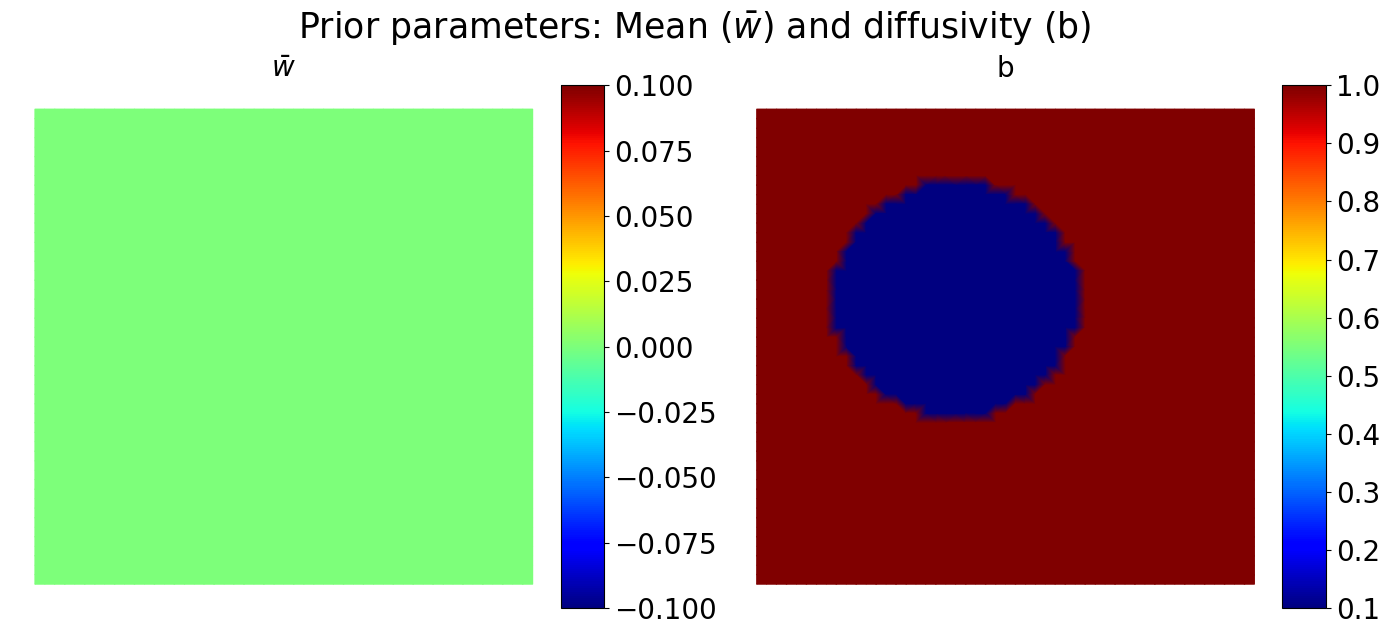

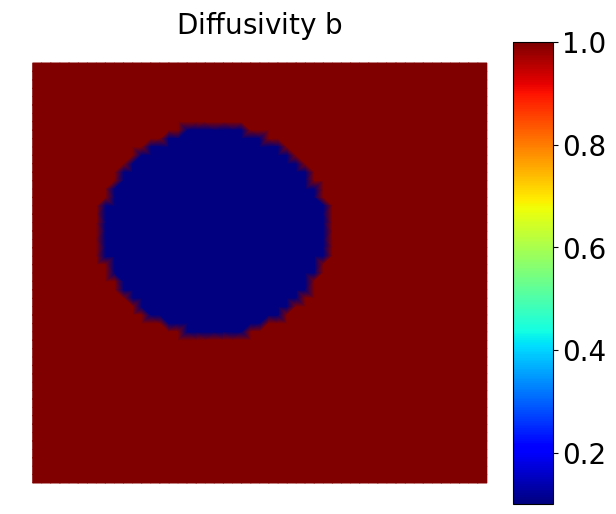

In [4]:
def modify_diffusivity(u, coords):
    xc, yc = 0.4, 0.6
    for i in range(coords.shape[0]):
        dx, dy = coords[i, 0] - xc, coords[i, 1] - yc
        u[i] = 0.1 if dx * dx + dy * dy < 0.25 * 0.25 else 1.0
    return u


prior_diffusion = function_to_vertex(prior_sampler.b_fn, V=V)
prior_diffusion = modify_diffusivity(prior_diffusion, nodes)
prior_sampler.set_diffusivity(prior_diffusion)

fs = 20
rows, cols = 1, 2
fig, axs = plt.subplots(rows, cols, figsize=(14, 6))
axs = np.array([axs]) if rows == 1 else axs

for j in range(cols):
    m = (
        prior_sampler.mean
        if j == 0
        else function_to_vertex(prior_sampler.b_fn, V=V)
    )
    cbar = field_plot(axs[0, j], m, nodes, cmap="jet")
    divider = make_axes_locatable(axs[0, j])
    cax = divider.append_axes("right", size="8%", pad=0.03)
    cax.tick_params(labelsize=fs)
    fig.colorbar(cbar, cax=cax, orientation="vertical")
    axs[0, j].set_title(r"$\bar{w}$" if j == 0 else r"$\mathsf{b}$", fontsize=fs)
    axs[0, j].axis("off")

fig.tight_layout()
fig.suptitle(
    r"Prior parameters: Mean ($\bar{w}$) and diffusivity ($\mathsf{b}$)",
    fontsize=1.25 * fs,
    y=1.05,
)
fig.savefig(results_dir / "inhomog_b_prior_parameters.png", bbox_inches="tight")
plt.show()

quick_field_plot(
    function_to_vertex(prior_sampler.b_fn, V=V),
    nodes,
    title=r"Diffusivity $\mathsf{b}$",
    cmap="jet",
    figsize=(7, 6),
    fs=20,
    savefilename=str(results_dir / "inhomog_b.png"),
)

Sample:  0, log_prior = -7.01e-01, min = -5.85e-01, max = 7.82e-01, mean = -8.08e-02, std = 1.59e-01
Sample:  1, log_prior = -7.08e-01, min = -7.96e-01, max = 6.09e-01, mean = -4.58e-02, std = 1.97e-01
Sample:  2, log_prior = -7.24e-01, min = -1.10e+00, max = 3.56e-01, mean = -9.80e-02, std = 2.12e-01
Sample:  3, log_prior = -7.20e-01, min = -7.09e-01, max = 8.03e-01, mean = -8.15e-03, std = 1.83e-01
Sample:  4, log_prior = -7.07e-01, min = -1.09e+00, max = 4.97e-01, mean = -6.87e-02, std = 2.11e-01
Sample:  5, log_prior = -7.07e-01, min = -6.71e-01, max = 9.45e-01, mean = -4.41e-03, std = 2.16e-01
Sample:  6, log_prior = -7.07e-01, min = -1.11e+00, max = 6.04e-01, mean = 1.75e-02, std = 2.43e-01
Sample:  7, log_prior = -7.05e-01, min = -1.01e+00, max = 8.71e-01, mean = 1.23e-01, std = 2.29e-01
Sample:  8, log_prior = -7.13e-01, min = -6.42e-01, max = 8.23e-01, mean = 2.21e-02, std = 1.55e-01
Statistics of all samples
Mean: min = -8.56e-01, max = 6.99e-01, mean = -1.59e-02, std = 2.01e

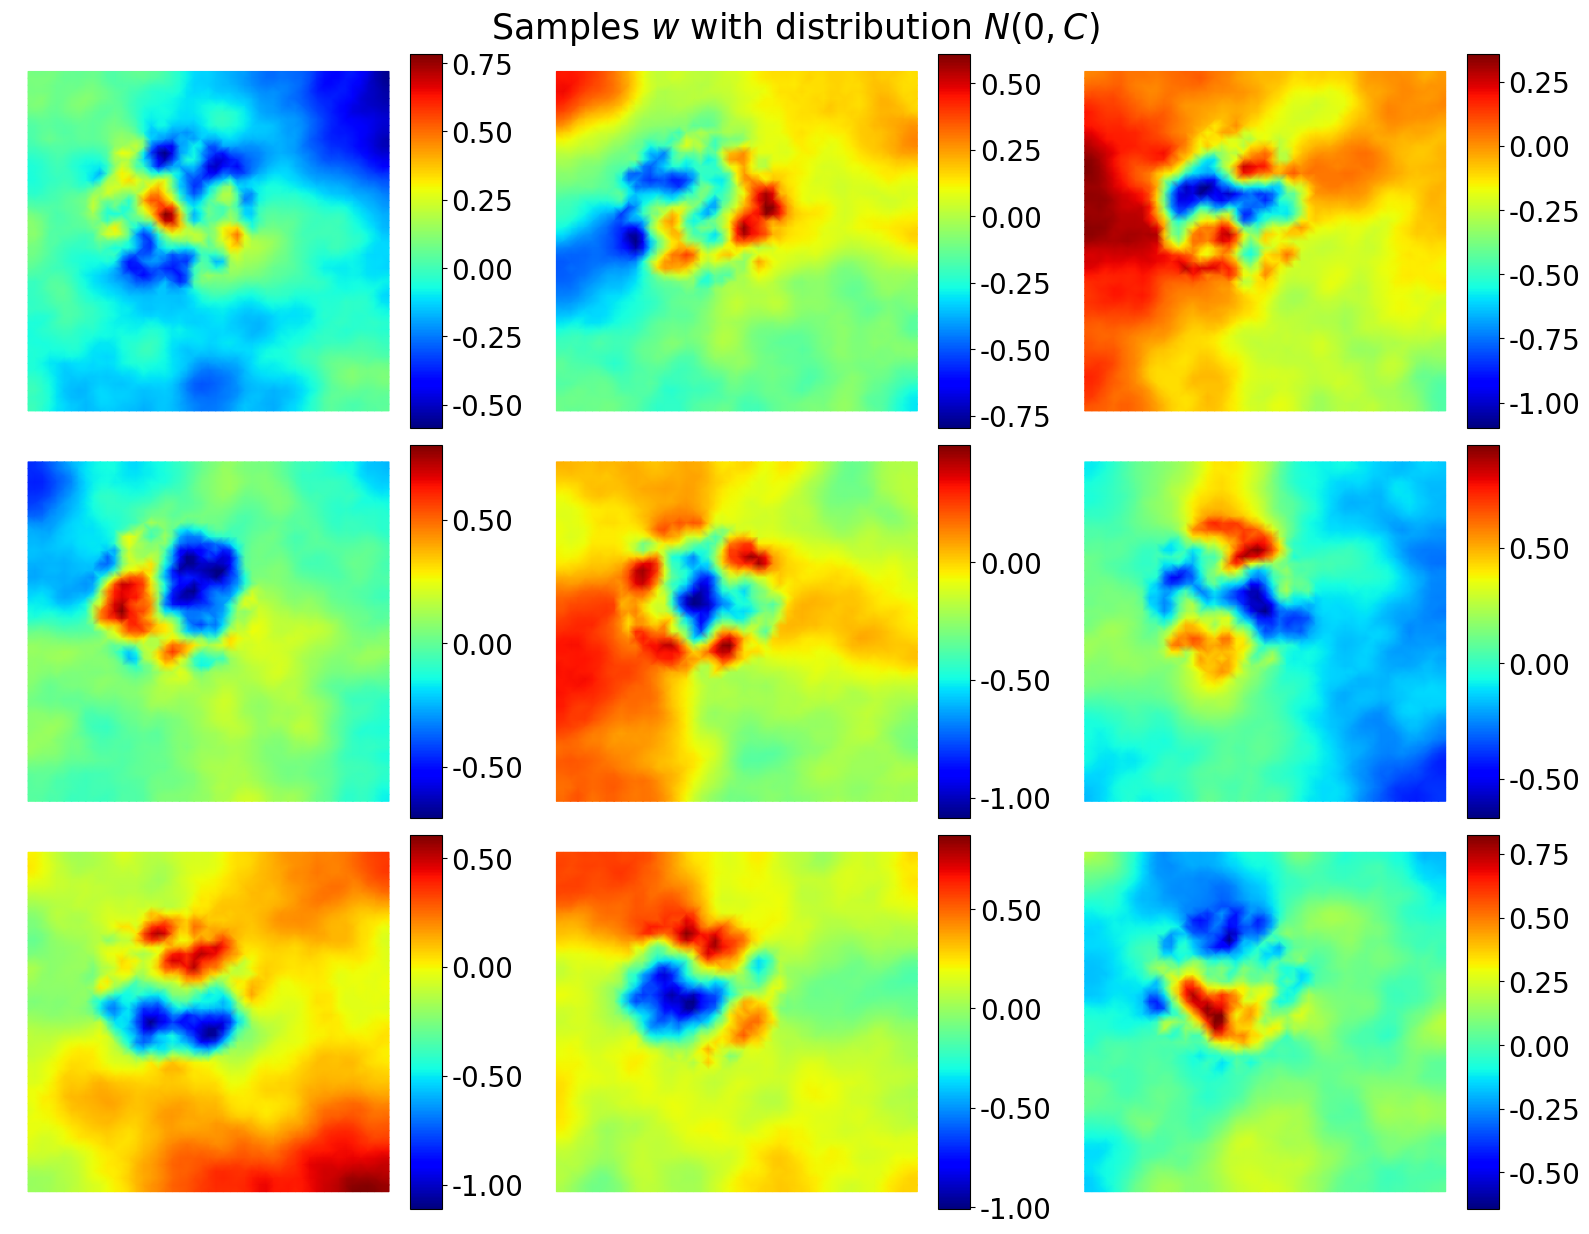

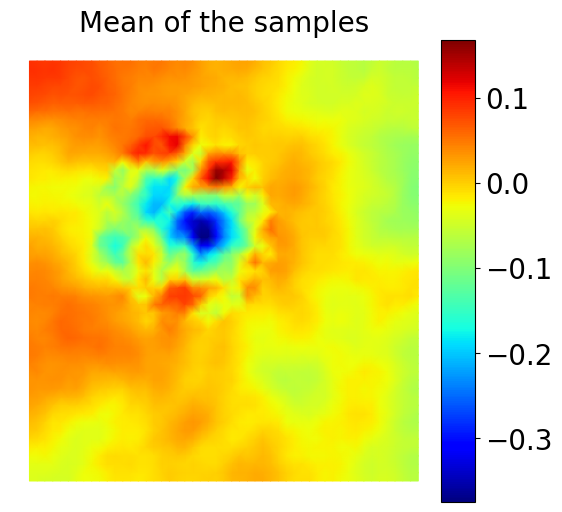

CPU times: user 1.11 s, sys: 1.12 s, total: 2.24 s
Wall time: 746 ms


In [5]:
%%time

fs = 20
rows, cols = 3, 3
fig, axs = plt.subplots(rows, cols, figsize=(16, 12))
stats = []
mvec = []
m = prior_sampler.empty_sample()

for i in range(rows):
    for j in range(cols):
        m, log_prior = prior_sampler(m)
        mvec.append(m)
        stats.append([np.min(m), np.max(m), np.mean(m), np.std(m), log_prior])
        print(
            f"Sample: {i * cols + j:2d}, log_prior = {log_prior:.2e}, "
            f"min = {np.min(m):.2e}, max = {np.max(m):.2e}, "
            f"mean = {np.mean(m):.2e}, std = {np.std(m):.2e}"
        )

        cbar = field_plot(axs[i, j], m, nodes, cmap="jet")
        divider = make_axes_locatable(axs[i, j])
        cax = divider.append_axes("right", size="8%", pad=0.03)
        cax.tick_params(labelsize=fs)
        kfmt = lambda x, pos: f"{x:.2f}"
        fig.colorbar(cbar, cax=cax, orientation="vertical", format=kfmt)
        axs[i, j].axis("off")

stats = np.array(stats)
print("Statistics of all samples")
print(
    f"Mean: min = {np.mean(stats[:, 0]):.2e}, max = {np.mean(stats[:, 1]):.2e}, "
    f"mean = {np.mean(stats[:, 2]):.2e}, std = {np.mean(stats[:, 3]):.2e}, "
    f"log_prior = {np.mean(stats[:, 4]):.2e}"
)

fig.tight_layout()
fig.suptitle(r"Samples $w$ with distribution $N(0,C)$", fontsize=1.25 * fs, y=1.025)
fig.savefig(results_dir / "inhomog_b_prior_samples.png", bbox_inches="tight")
plt.show()

mvec = np.array(mvec)
quick_field_plot(
    np.mean(mvec, axis=0),
    nodes,
    title="Mean of the samples",
    cmap="jet",
)

## Revert diffusivity to constant 1

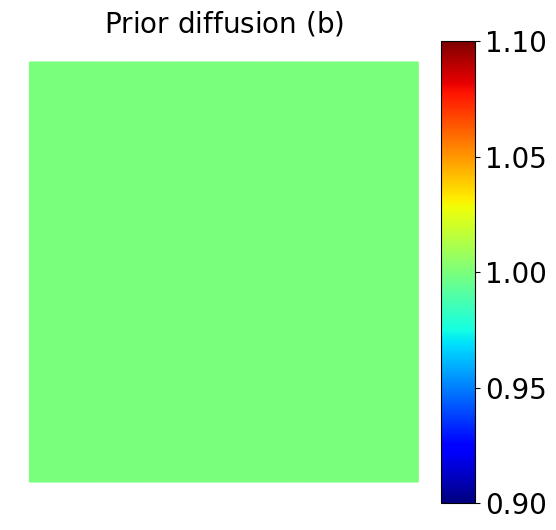

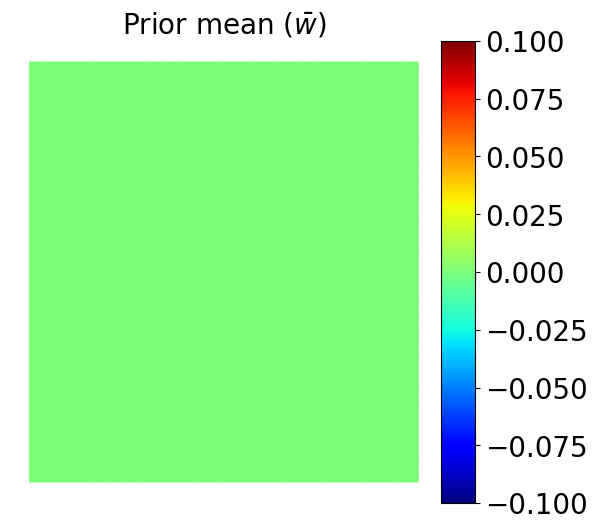

In [6]:
prior_diffusion[:] = 1.0
prior_sampler.set_diffusivity(prior_diffusion)

quick_field_plot(
    function_to_vertex(prior_sampler.b_fn, V=V),
    nodes,
    title=r"Prior diffusion ($\mathsf{b}$)",
)
quick_field_plot(
    prior_sampler.mean,
    nodes,
    title=r"Prior mean ($\bar{w}$)",
)

## Smooth diffusivity

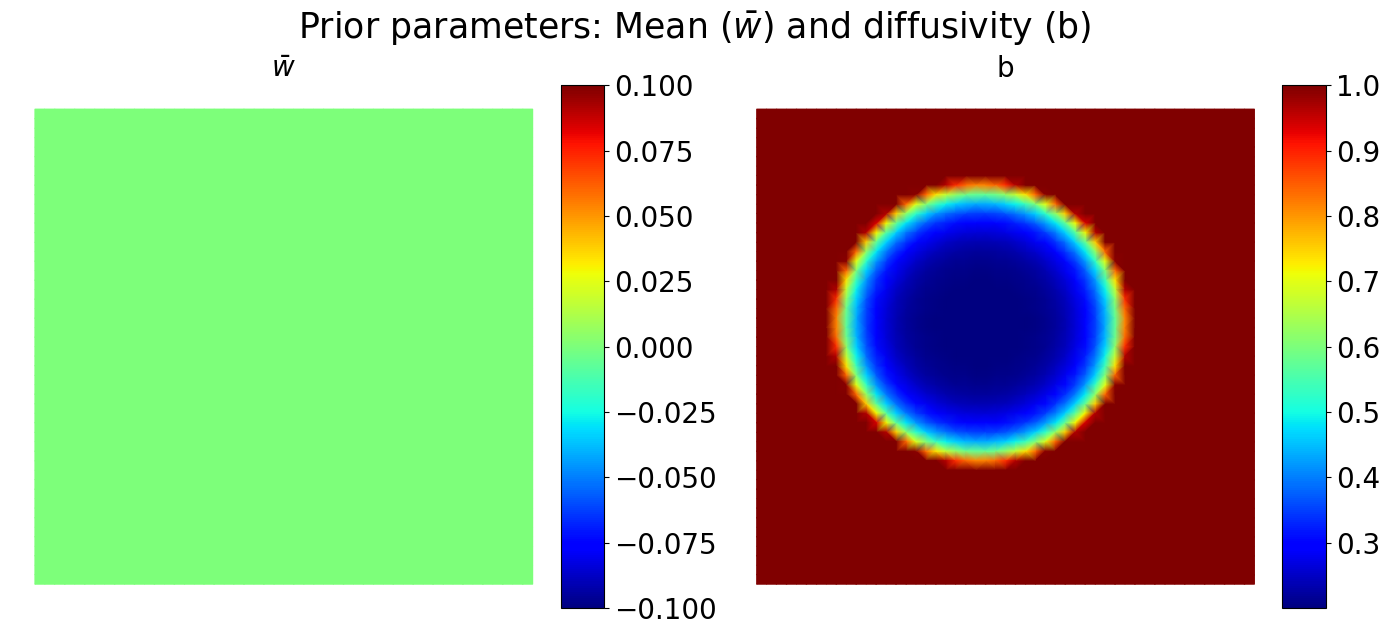

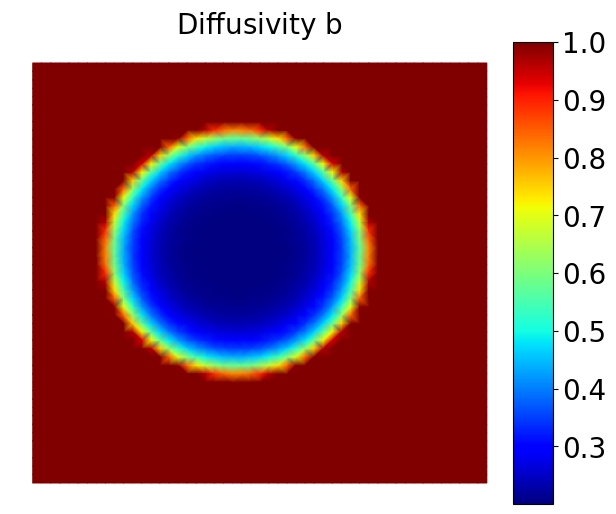

In [7]:
def modify_diffusivity_smooth(u, coords):
    xc, yc, r = 0.45, 0.55, 0.3
    n = 2
    vin, vout = 0.2, 1.0
    a, b = vin, -np.log(vout / vin)
    tol = 1.0e-12

    for i in range(coords.shape[0]):
        xx, yy = coords[i, 0] - xc, coords[i, 1] - yc
        f = np.power(np.sqrt(xx * xx + yy * yy) / r, n)
        u[i] = a * np.exp(-b * f * f) if f < 1.0 + tol else vout
    return u


prior_diffusion = function_to_vertex(prior_sampler.b_fn, V=V)
prior_diffusion = modify_diffusivity_smooth(prior_diffusion, nodes)
prior_sampler.set_diffusivity(prior_diffusion)

fs = 20
rows, cols = 1, 2
fig, axs = plt.subplots(rows, cols, figsize=(14, 6))
axs = np.array([axs]) if rows == 1 else axs

for j in range(cols):
    m = (
        prior_sampler.mean
        if j == 0
        else function_to_vertex(prior_sampler.b_fn, V=V)
    )
    cbar = field_plot(axs[0, j], m, nodes, cmap="jet")
    divider = make_axes_locatable(axs[0, j])
    cax = divider.append_axes("right", size="8%", pad=0.03)
    cax.tick_params(labelsize=fs)
    fig.colorbar(cbar, cax=cax, orientation="vertical")
    axs[0, j].set_title(r"$\bar{w}$" if j == 0 else r"$\mathsf{b}$", fontsize=fs)
    axs[0, j].axis("off")

fig.tight_layout()
fig.suptitle(
    r"Prior parameters: Mean ($\bar{w}$) and diffusivity ($\mathsf{b}$)",
    fontsize=1.25 * fs,
    y=1.05,
)
fig.savefig(results_dir / "smooth_b_prior_parameters.png", bbox_inches="tight")
plt.show()

quick_field_plot(
    function_to_vertex(prior_sampler.b_fn, V=V),
    nodes,
    title=r"Diffusivity $\mathsf{b}$",
    cmap="jet",
    figsize=(7, 6),
    fs=20,
    savefilename=str(results_dir / "smooth_b.png"),
)

Sample:  0, log_prior = -7.04e-01, min = -7.13e-01, max = 1.96e-01, mean = -2.00e-01, std = 1.43e-01
Sample:  1, log_prior = -7.05e-01, min = -2.36e-01, max = 3.63e-01, mean = 4.29e-02, std = 1.40e-01
Sample:  2, log_prior = -7.07e-01, min = -4.02e-01, max = 4.36e-01, mean = 4.84e-02, std = 1.62e-01
Sample:  3, log_prior = -7.23e-01, min = -5.27e-01, max = 5.40e-01, mean = 8.63e-03, std = 2.07e-01
Sample:  4, log_prior = -7.00e-01, min = -4.59e-01, max = 3.74e-01, mean = 2.06e-03, std = 1.62e-01
Sample:  5, log_prior = -6.89e-01, min = -4.95e-01, max = 2.95e-01, mean = -1.47e-01, std = 1.82e-01
Sample:  6, log_prior = -6.90e-01, min = -4.61e-01, max = 4.93e-01, mean = -9.09e-02, std = 1.53e-01
Sample:  7, log_prior = -7.27e-01, min = -3.50e-01, max = 4.03e-01, mean = -3.70e-02, std = 9.28e-02
Sample:  8, log_prior = -6.98e-01, min = -1.80e-01, max = 3.87e-01, mean = 5.97e-02, std = 1.02e-01
Statistics of all samples
Mean: min = -4.25e-01, max = 3.88e-01, mean = -3.48e-02, std = 1.49e-0

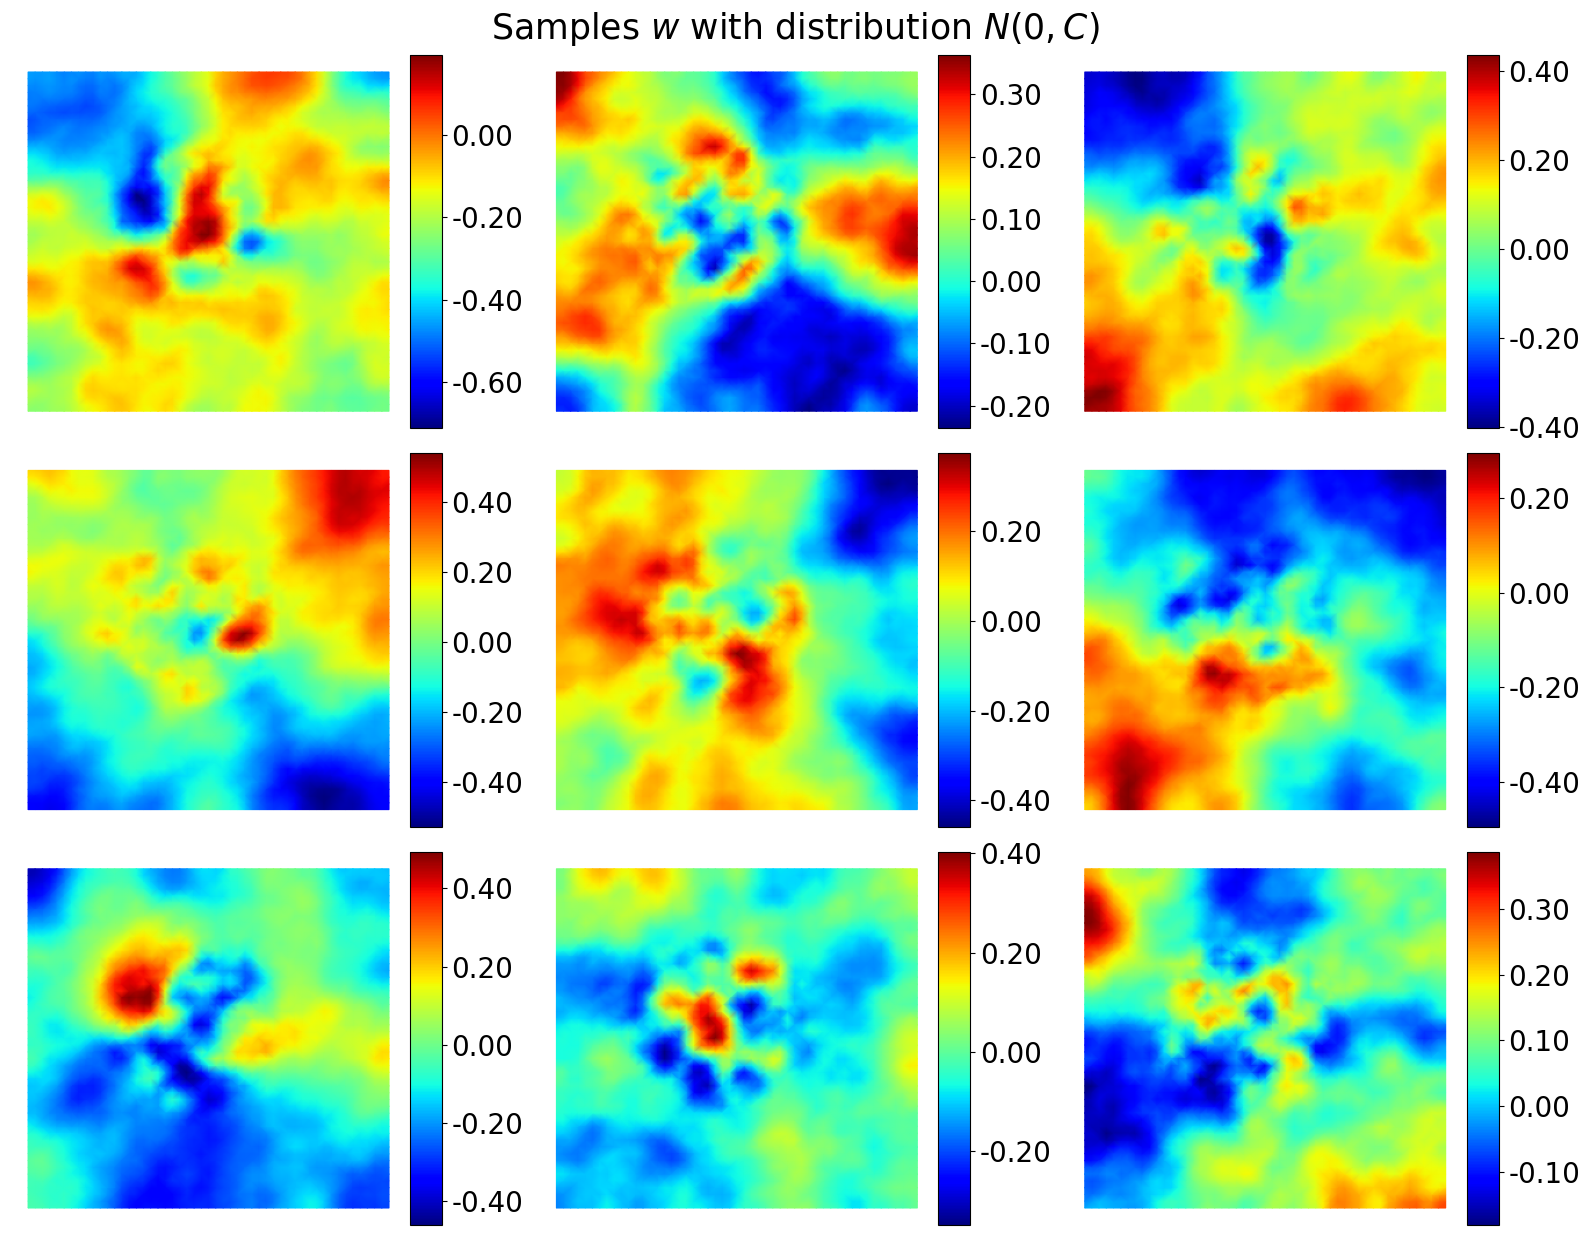

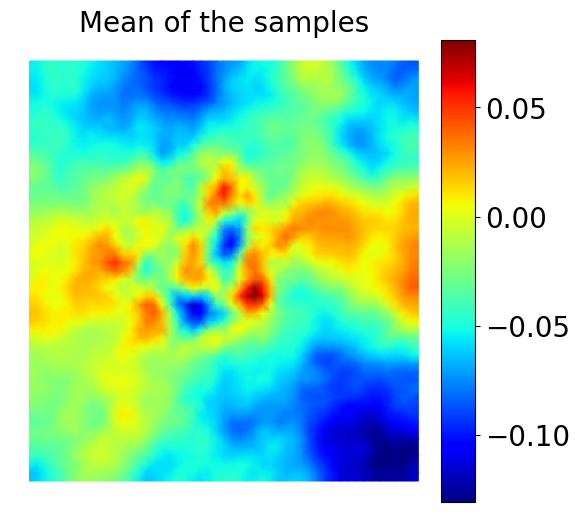

CPU times: user 1.2 s, sys: 1.21 s, total: 2.4 s
Wall time: 810 ms


In [8]:
%%time

fs = 20
rows, cols = 3, 3
fig, axs = plt.subplots(rows, cols, figsize=(16, 12))
stats = []
mvec = []
m = prior_sampler.empty_sample()

for i in range(rows):
    for j in range(cols):
        m, log_prior = prior_sampler(m)
        mvec.append(m)
        stats.append([np.min(m), np.max(m), np.mean(m), np.std(m), log_prior])
        print(
            f"Sample: {i * cols + j:2d}, log_prior = {log_prior:.2e}, "
            f"min = {np.min(m):.2e}, max = {np.max(m):.2e}, "
            f"mean = {np.mean(m):.2e}, std = {np.std(m):.2e}"
        )

        cbar = field_plot(axs[i, j], m, nodes, cmap="jet")
        divider = make_axes_locatable(axs[i, j])
        cax = divider.append_axes("right", size="8%", pad=0.03)
        cax.tick_params(labelsize=fs)
        kfmt = lambda x, pos: f"{x:.2f}"
        fig.colorbar(cbar, cax=cax, orientation="vertical", format=kfmt)
        axs[i, j].axis("off")

stats = np.array(stats)
print("Statistics of all samples")
print(
    f"Mean: min = {np.mean(stats[:, 0]):.2e}, max = {np.mean(stats[:, 1]):.2e}, "
    f"mean = {np.mean(stats[:, 2]):.2e}, std = {np.mean(stats[:, 3]):.2e}, "
    f"log_prior = {np.mean(stats[:, 4]):.2e}"
)

fig.tight_layout()
fig.suptitle(r"Samples $w$ with distribution $N(0,C)$", fontsize=1.25 * fs, y=1.025)
fig.savefig(results_dir / "smooth_b_prior_samples.png", bbox_inches="tight")
plt.show()

mvec = np.array(mvec)
quick_field_plot(
    np.mean(mvec, axis=0),
    nodes,
    title="Mean of the samples",
    cmap="jet",
)